In [1]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('diabetes.csv')

In [2]:
df.shape

(768, 9)

In [3]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

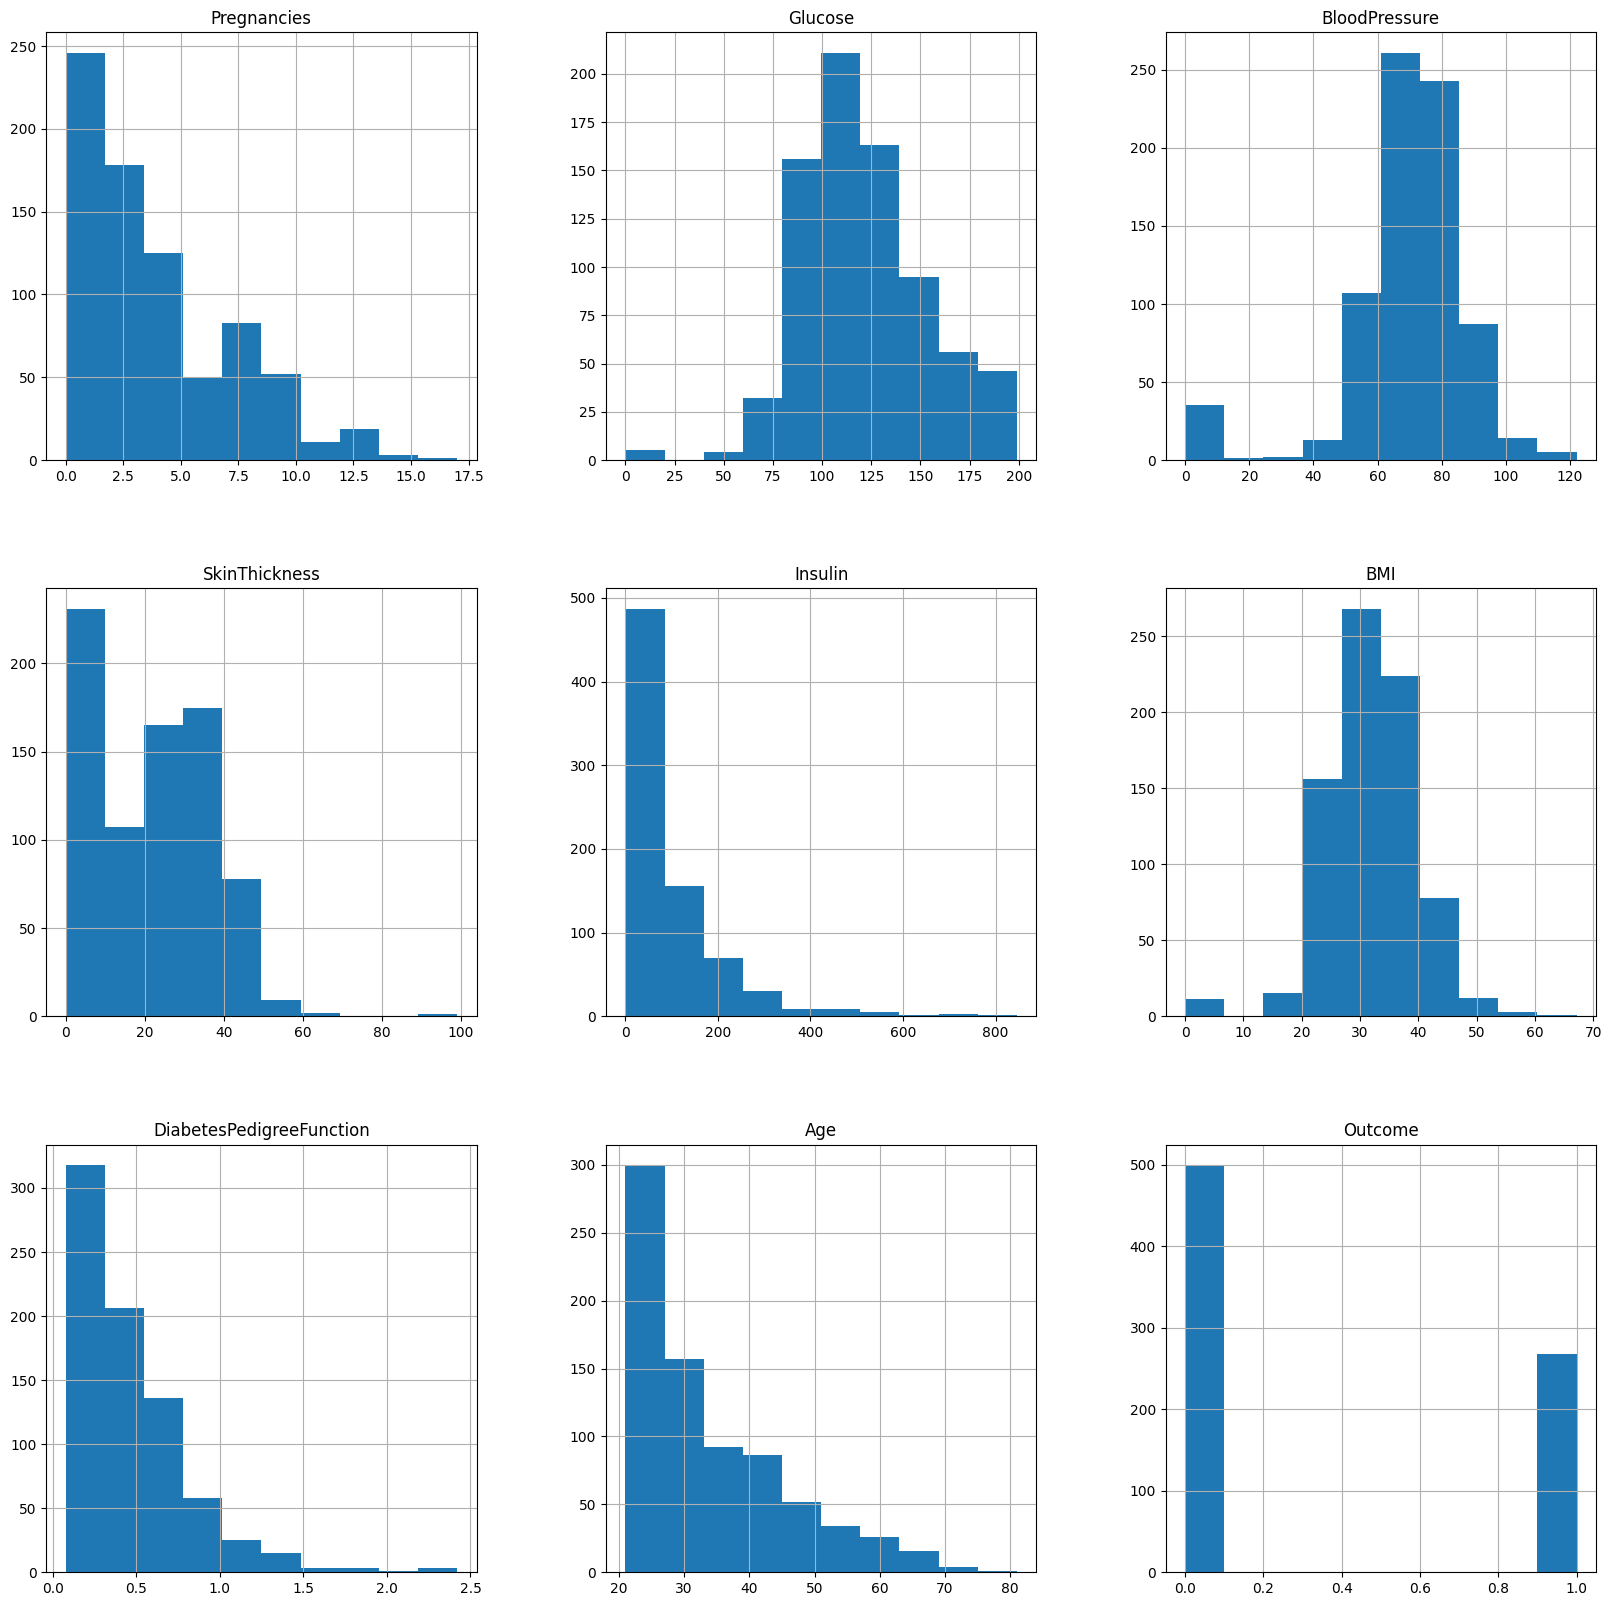

In [6]:
df.hist(figsize = (20,20))

# Finding the Zeros

In [7]:
# Create a list of the columns we know shouldn't have 0s
sus_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in sus_cols:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [8]:
# Replace 0s with NaN only in above specific columns
df[sus_cols] = df[sus_cols].replace(0, np.nan)

# Now check the true missing values
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [9]:
from sklearn.impute import KNNImputer

# n_neighbors=5 means it will look at the 5 most similar patients to guess the missing value
imputer = KNNImputer(n_neighbors=5)

In [10]:
# NOTE: sklearn imputers output a raw NumPy array, stripping away your column names!
imp_array = imputer.fit_transform(df)

# Converting back to Pandas DataFrame
# We pass the original columns so it looks exactly like our old dataframe
df_clean = pd.DataFrame(imp_array, columns=df.columns)

# Final Null values Check
print("Missing values after imputation:\n", df_clean.isnull().sum())

Missing values after imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Text(0.5, 1.0, 'Glucose Levels by Diabetic Outcome')

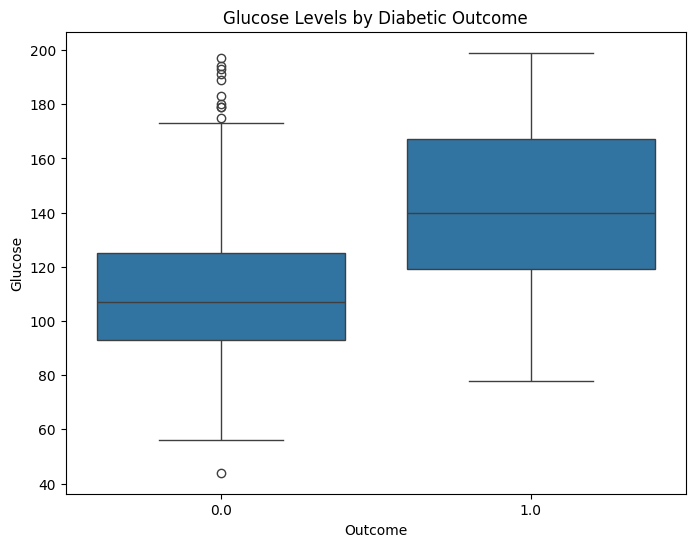

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (8,6))

sns.boxplot(x='Outcome', y='Glucose', data=df_clean)

plt.title('Glucose Levels by Diabetic Outcome')

Text(0.5, 1.0, 'Feature Correlation Matrix')

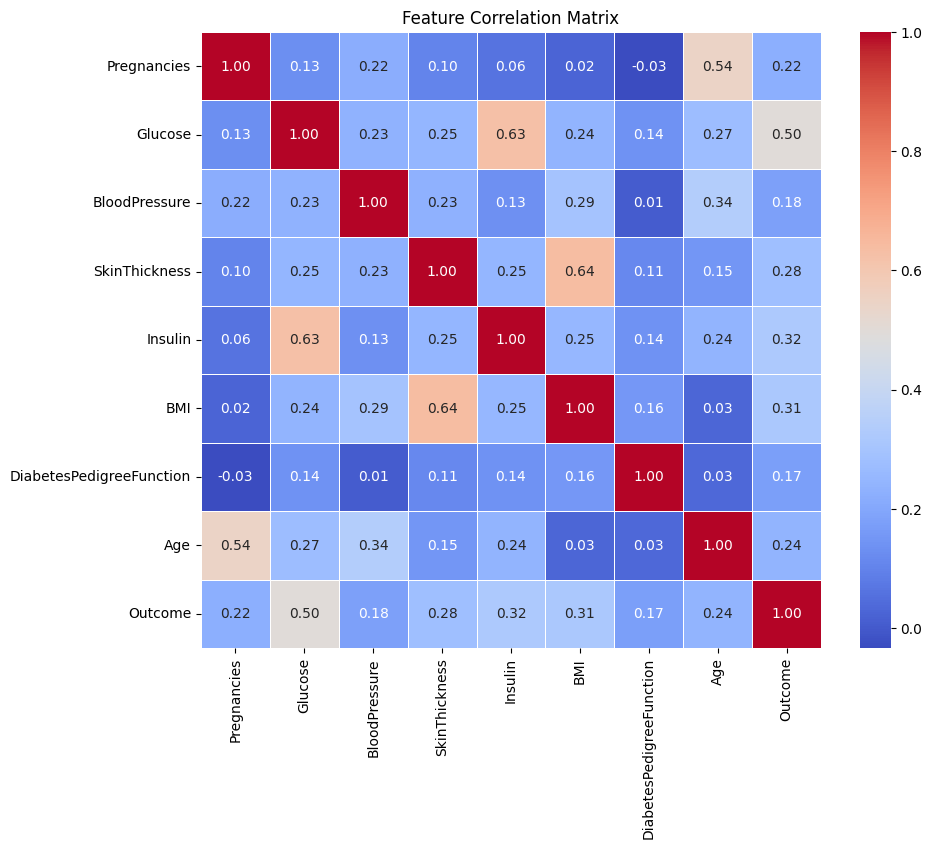

In [12]:
# import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# .corr() calculates the Pearson correlation coefficient between all columns
# annot=True puts the actual numbers in the squares
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Matrix')

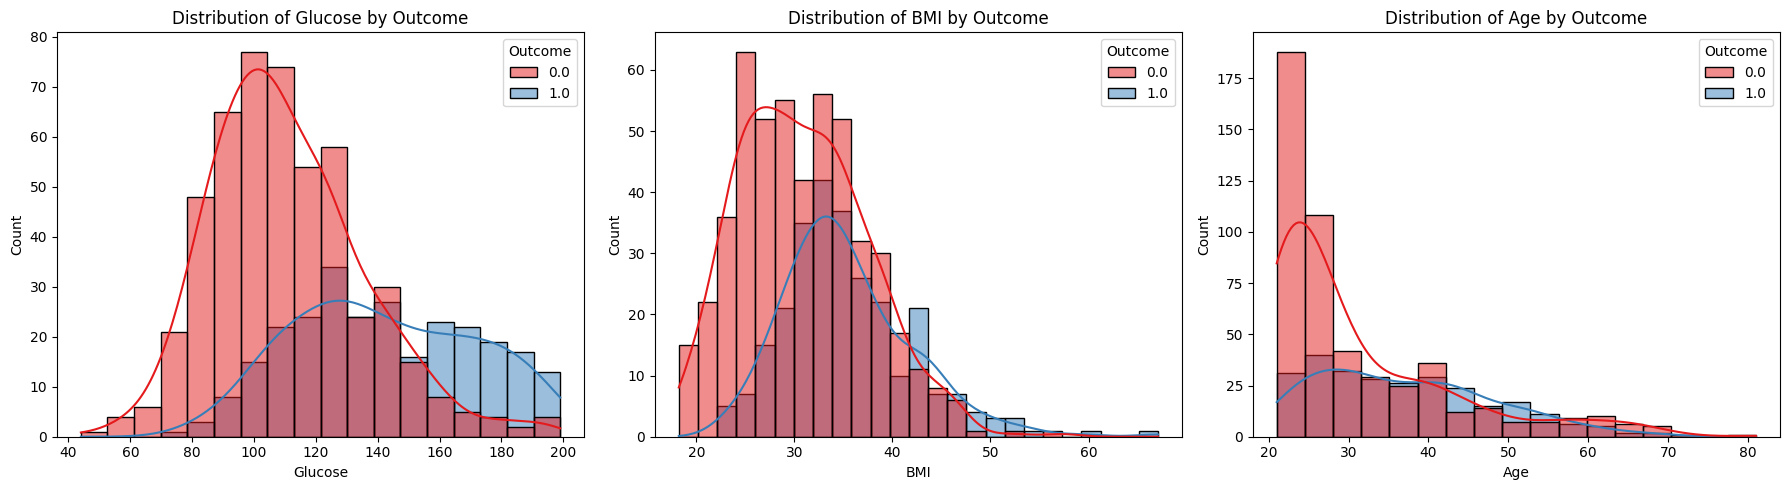

In [13]:
# Let's plot the top 3 most important features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_feat = ['Glucose', 'BMI', 'Age']

for i, feature in enumerate(top_feat):
    sns.histplot(data=df_clean, x=feature, hue='Outcome', kde=True, ax=axes[i], palette='Set1', alpha=0.5)
    axes[i].set_title(f'Distribution of {feature} by Outcome')

plt.tight_layout()
plt.show()

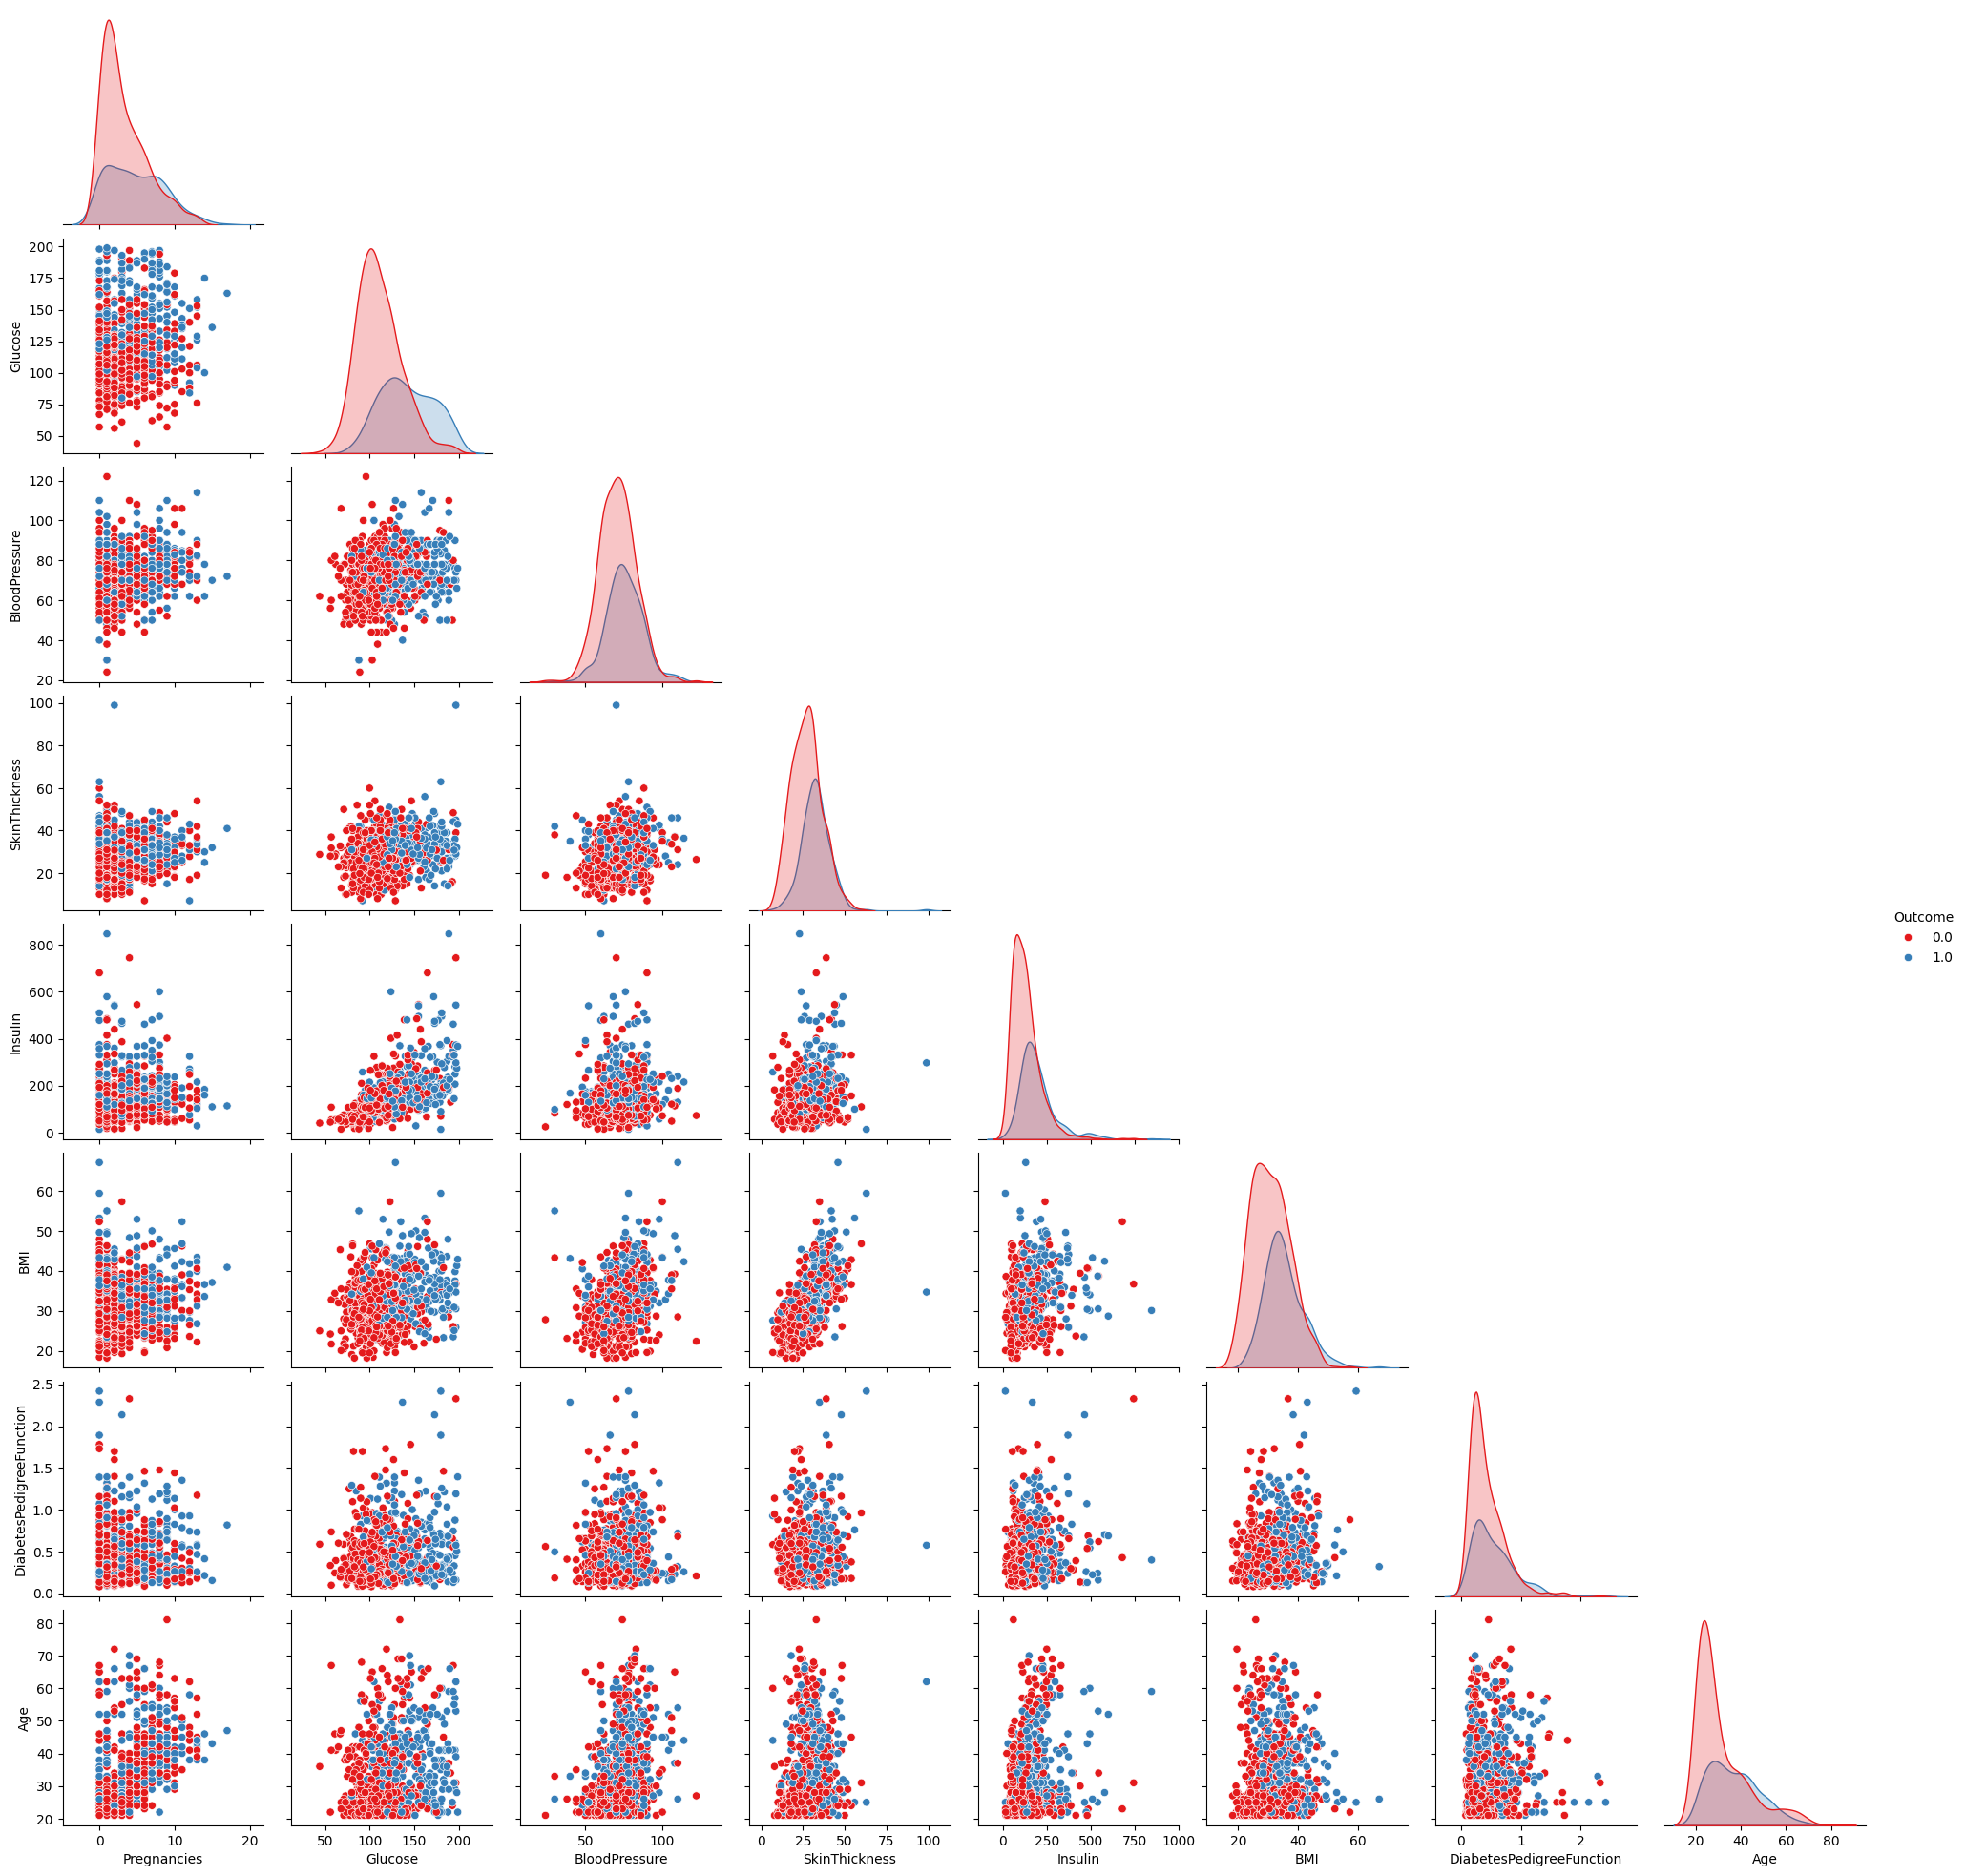

In [14]:
sns.pairplot(df_clean, hue='Outcome', corner=True, palette='Set1', diag_kind='kde')

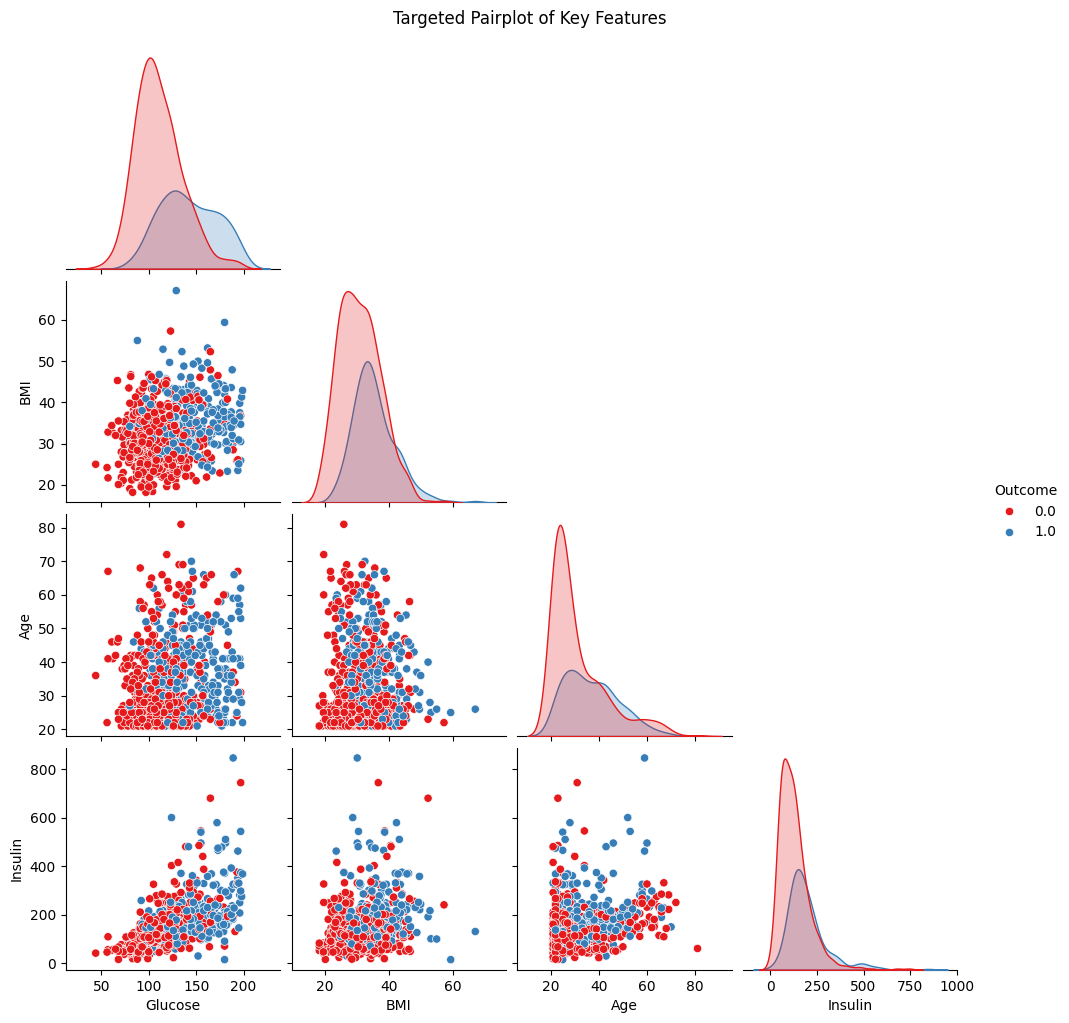

In [15]:
# We only pass our highly correlated features plus the Outcome column
target_cols = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']

# corner=True removes the duplicate plots on the top-right half of the grid
sns.pairplot(df_clean[target_cols], hue='Outcome', corner=True, palette='Set1', diag_kind='kde')

plt.suptitle('Targeted Pairplot of Key Features', y=1.02)
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,       # Keep 20% of the data hidden for the final test
    random_state=42,     # Ensures you get the exact same split every time you run the code
    stratify=y           # MOST IMPORTANT PARAMETER FOR THIS DATASET
)

# We had roughly 500 non-diabetics and 268 diabetics. If we randomly shuffle and split the data, we might accidentally put all the diabetic cases in the training set and none in the test set.
#stratify=y forces the split to maintain that exact 2:1 ratio in both the training set and the testing set.

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

smote = SMOTE(random_state=42)

# Resample the TRAINING data only!
# This generates synthetic diabetic patients until y_train_resampled is 50/50
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scale the new balanced data
scaler = StandardScaler()

# Fit/Transform on the new synthetic training data
X_train_scaled = scaler.fit_transform(X_train_res)

# Transform the original, untouched test data
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# Initialize the Models in a Dictionary
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Create a list to store our comparison metrics
comparison_metrics = []

# Train and Evaluate in a Loop
for name, model in models.items():
    print(f"\n{name}")
    
    # Train the model
    model.fit(X_train_scaled, y_train_res)
    
    # Make standard predictions (0 or 1)
    y_pred = model.predict(X_test_scaled)
    
    # Make probability predictions for ROC-AUC
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate ROC-AUC
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Print the detailed Classification Report
    print(classification_report(y_test, y_pred))
    
    # Save the ROC-AUC score for our final leaderboard
    comparison_metrics.append({
        "Model": name,
        "ROC-AUC": roc_auc
    })

# Display the Final Leaderboard
print("FINAL MODEL LEADERBOARD")
leaderboard_df = pd.DataFrame(comparison_metrics).sort_values(by="ROC-AUC", ascending=False)
print(leaderboard_df.to_string(index=False))

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.83      0.74      0.78       100
         1.0       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

Random Forest
              precision    recall  f1-score   support

         0.0       0.82      0.77      0.79       100
         1.0       0.62      0.69      0.65        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154

XGBoost
              precision    recall  f1-score   support

         0.0       0.82      0.80      0.81       100
         1.0       0.64      0.67      0.65        54

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.76      0.7

In [63]:
import optuna
from sklearn.model_selection import cross_val_score

# Define the Objective Function
def objective(trial):
    # Tell Optuna which hyperparameters to "suggest" and their ranges
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 15)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    
    # Initialize the model with Optuna's current guesses
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        class_weight=class_weight,
        random_state=42
    )
    
    # Evaluate the model
    # cv=3 means it trains/tests 3 times per trial to ensure stability
    score = cross_val_score(
        clf, 
        X_train_scaled, 
        y_train_res, 
        cv=3, 
        scoring='roc_auc'
    )
    
    # Return the average ROC-AUC score for Optuna to evaluate
    return np.mean(score)

# Create the "Study" and run the optimization
# direction='maximize' because we want the highest ROC-AUC score possible
study = optuna.create_study(direction='maximize', study_name="RF_Diabetes_Tuning")

# n_trials=50 means Optuna gets 50 smart guesses to find the best combo
print("Starting Optuna optimization...")
study.optimize(objective, n_trials=50)

# Extract the winning parameters
print("\n--- OPTUNA TUNING RESULTS ---")
print(f"Best ROC-AUC Score from CV: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train the Final Model with the best parameters
best_rf_optuna = RandomForestClassifier(**study.best_params, random_state=42)
best_rf_optuna.fit(X_train_scaled, y_train_res)

# Final Test on the completely hidden test set
y_pred_optuna = best_rf_optuna.predict(X_test_scaled)
print("\n--- FINAL CLASSIFICATION REPORT (OPTUNA TUNED) ---")
print(classification_report(y_test, y_pred_optuna))

[I 2026-06-27 02:29:19,692] A new study created in memory with name: RF_Diabetes_Tuning


Starting Optuna optimization...


[I 2026-06-27 02:29:20,558] Trial 0 finished with value: 0.8798137190130527 and parameters: {'n_estimators': 104, 'max_depth': 21, 'min_samples_split': 8, 'class_weight': None}. Best is trial 0 with value: 0.8798137190130527.
[I 2026-06-27 02:29:21,524] Trial 1 finished with value: 0.8820518077822769 and parameters: {'n_estimators': 95, 'max_depth': 22, 'min_samples_split': 9, 'class_weight': None}. Best is trial 1 with value: 0.8820518077822769.
[I 2026-06-27 02:29:22,354] Trial 2 finished with value: 0.879364273099987 and parameters: {'n_estimators': 82, 'max_depth': 18, 'min_samples_split': 12, 'class_weight': None}. Best is trial 1 with value: 0.8820518077822769.
[I 2026-06-27 02:29:22,857] Trial 3 finished with value: 0.876791068682817 and parameters: {'n_estimators': 55, 'max_depth': 26, 'min_samples_split': 11, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8820518077822769.
[I 2026-06-27 02:29:25,569] Trial 4 finished with value: 0.8941040177595824 and parameters: {


--- OPTUNA TUNING RESULTS ---
Best ROC-AUC Score from CV: 0.8949
Best Parameters:
  n_estimators: 246
  max_depth: 22
  min_samples_split: 2
  class_weight: None

--- FINAL CLASSIFICATION REPORT (OPTUNA TUNED) ---
              precision    recall  f1-score   support

         0.0       0.83      0.79      0.81       100
         1.0       0.64      0.70      0.67        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



In [64]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Define the Objective Function
def objective(trial):
    # The XGBoost Hyperparameter Grid
    param = {
        # n_estimators: How many trees to build
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        
        # max_depth: How deep each tree can grow (Keep lower than Random Forest!)
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        
        # learning_rate: How aggressively each tree tries to fix the previous tree's mistakes
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        
        # subsample: % of rows (patients) used per tree (Prevents overfitting)
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        
        # colsample_bytree: % of columns (features) used per tree (Adds randomness)
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        
        # min_child_weight: Minimum sum of weights needed in a child node (Higher = more conservative)
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        
        # Standard settings
        'eval_metric': 'logloss',
        'random_state': 42
    }
    
    # Initialize XGBoost with the trial parameters
    clf = XGBClassifier(**param)
    
    # Evaluate using Cross Validation on the SMOTE training data
    score = cross_val_score(
        clf, 
        X_train_scaled, 
        y_train_res, 
        cv=3, 
        scoring='roc_auc'
    )
    
    return np.mean(score)

# 2. Create the Study
# We still want to maximize the ROC-AUC score
study = optuna.create_study(direction='maximize', study_name="XGB_Diabetes_Tuning")

# n_trials=50 gives Optuna 50 attempts to find the perfect architecture
print("Starting XGBoost Optuna optimization...")
study.optimize(objective, n_trials=50)

# 3. Extract the winning parameters
print("\n--- OPTUNA TUNING RESULTS (XGBOOST) ---")
print(f"Best ROC-AUC Score from CV: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# 4. Train the Final Model
# Notice we pass the eval_metric and random_state manually alongside the tuned params
best_xgb_optuna = XGBClassifier(**study.best_params, eval_metric='logloss', random_state=42)
best_xgb_optuna.fit(X_train_scaled, y_train_res)

# 5. Final Test on the hidden test set
y_pred_xgb = best_xgb_optuna.predict(X_test_scaled)
print("\n--- FINAL CLASSIFICATION REPORT (XGBOOST TUNED) ---")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))

[I 2026-06-27 02:30:59,763] A new study created in memory with name: XGB_Diabetes_Tuning


Starting XGBoost Optuna optimization...


[I 2026-06-27 02:31:01,097] Trial 0 finished with value: 0.8735490392460784 and parameters: {'n_estimators': 443, 'max_depth': 3, 'learning_rate': 0.02285985570483156, 'subsample': 0.7950908441600151, 'colsample_bytree': 0.6152545446872029, 'min_child_weight': 2}. Best is trial 0 with value: 0.8735490392460784.
[I 2026-06-27 02:31:01,981] Trial 1 finished with value: 0.8620094169887742 and parameters: {'n_estimators': 241, 'max_depth': 10, 'learning_rate': 0.2292717291476846, 'subsample': 0.9544455930593299, 'colsample_bytree': 0.5793742378555005, 'min_child_weight': 7}. Best is trial 0 with value: 0.8735490392460784.
[I 2026-06-27 02:31:02,953] Trial 2 finished with value: 0.8758520979814591 and parameters: {'n_estimators': 201, 'max_depth': 6, 'learning_rate': 0.034736667799177716, 'subsample': 0.903580401170671, 'colsample_bytree': 0.550572769551279, 'min_child_weight': 5}. Best is trial 2 with value: 0.8758520979814591.
[I 2026-06-27 02:31:04,311] Trial 3 finished with value: 0.868


--- OPTUNA TUNING RESULTS (XGBOOST) ---
Best ROC-AUC Score from CV: 0.8851
Best Parameters:
  n_estimators: 318
  max_depth: 8
  learning_rate: 0.09255818624601017
  subsample: 0.5833833861354241
  colsample_bytree: 0.7762421165653387
  min_child_weight: 1

--- FINAL CLASSIFICATION REPORT (XGBOOST TUNED) ---
              precision    recall  f1-score   support

         0.0       0.81      0.79      0.80       100
         1.0       0.63      0.67      0.65        54

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



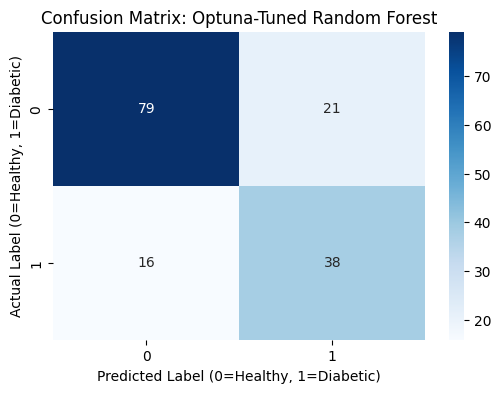

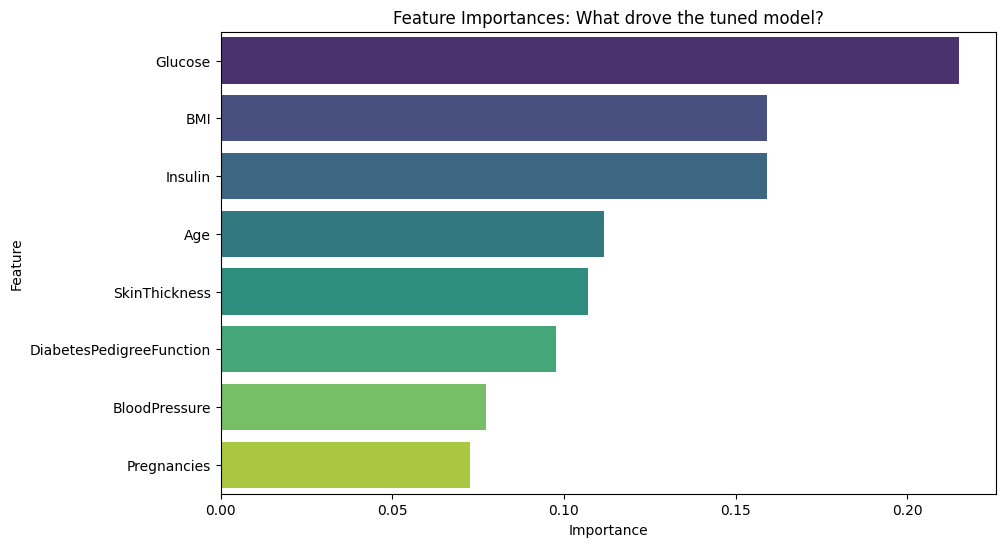


--- FINAL FEATURE IMPORTANCE SCORES ---
                    Feature  Importance
1                   Glucose    0.214986
5                       BMI    0.159274
4                   Insulin    0.159076
7                       Age    0.111753
3             SkinThickness    0.107162
6  DiabetesPedigreeFunction    0.097853
2             BloodPressure    0.077328
0               Pregnancies    0.072567


In [65]:
# ==========================================
# 1. THE CONFUSION MATRIX
# ==========================================
# We use y_pred_optuna (the predictions from your tuned Random Forest)
cm = confusion_matrix(y_test, y_pred_optuna)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Optuna-Tuned Random Forest')
plt.xlabel('Predicted Label (0=Healthy, 1=Diabetic)')
plt.ylabel('Actual Label (0=Healthy, 1=Diabetic)')
plt.show()

# ==========================================
# 2. FEATURE IMPORTANCE
# ==========================================
# Extract the built-in importances directly from the winning model
importances = best_rf_optuna.feature_importances_

# Grab the original column names (everything except 'Outcome')
feature_names = df.drop('Outcome', axis=1).columns 

# Create a clean DataFrame and sort it from highest to lowest impact
importance_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df, palette='viridis', legend=False)
plt.title('Feature Importances: What drove the tuned model?')
plt.show()

# Print the raw numbers for your records
print("\n--- FINAL FEATURE IMPORTANCE SCORES ---")
print(importance_df)

##### Why Random Forest? In clinical data, features often interact in complex, non-linear ways (e.g., high BMI is dangerous, but high BMI combined with high Age is exponentially more dangerous). Simple models like Logistic Regression struggle with this. Random Forest builds hundreds of "Decision Trees," lets them all vote, and outputs the majority decision. It is incredibly robust and resistant to overfitting.